# 3. Advanced Analysis
**Dataset:** Customer Churn (Telecom) — `data/cleaned_data.csv`
**Goal:** Statistically validate patterns from EDA and build a predictive model to quantify churn drivers.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

sns.set_style('whitegrid')
df = pd.read_csv('../data/cleaned_data.csv')
df.shape

(500, 11)

## 3.1 Hypothesis Testing

**H1:** Tenure differs significantly between churned and retained customers.
**H2:** Contract type and churn are dependent (not independent).
**H3:** Monthly charges differ significantly between churned and retained customers.


In [28]:
# H1: Independent t-test on Tenure
churned_tenure = df[df['Churn'] == 1]['Tenure']
retained_tenure = df[df['Churn'] == 0]['Tenure']

t_stat, p_val = stats.ttest_ind(churned_tenure, retained_tenure, equal_var=False)
print(f"H1 - Tenure t-test: t={t_stat:.3f}, p={p_val:.5f}")
print("Reject H0 (means differ)" if p_val < 0.05 else "Fail to reject H0")
print(f"Mean tenure - Churned: {churned_tenure.mean():.1f}, Retained: {retained_tenure.mean():.1f}")

H1 - Tenure t-test: t=-34.535, p=0.00000
Reject H0 (means differ)
Mean tenure - Churned: 6.0, Retained: 40.2


In [29]:
# H2: Chi-square test of independence - Contract vs Churn
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"H2 - Chi-square: chi2={chi2:.3f}, p={p_val:.5f}, dof={dof}")
print("Reject H0 (Contract and Churn are dependent)" if p_val < 0.05 else "Fail to reject H0")
contingency

H2 - Chi-square: chi2=27.715, p=0.00000, dof=2
Reject H0 (Contract and Churn are dependent)


Churn,0,1
Contract,,
Month-to-month,135,35
One year,178,8
Two year,134,10


In [30]:
# H3: Independent t-test on MonthlyCharges
churned_mc = df[df['Churn'] == 1]['MonthlyCharges']
retained_mc = df[df['Churn'] == 0]['MonthlyCharges']

t_stat2, p_val2 = stats.ttest_ind(churned_mc, retained_mc, equal_var=False)
print(f"H3 - MonthlyCharges t-test: t={t_stat2:.3f}, p={p_val2:.5f}")
print("Reject H0 (means differ)" if p_val2 < 0.05 else "Fail to reject H0")
print(f"Mean MonthlyCharges - Churned: {churned_mc.mean():.1f}, Retained: {retained_mc.mean():.1f}")

H3 - MonthlyCharges t-test: t=2.646, p=0.01008
Reject H0 (means differ)
Mean MonthlyCharges - Churned: 129.8, Retained: 111.7


In [31]:
# Chi-square: PaymentMethod vs Churn (exploratory 4th test)
contingency2 = pd.crosstab(df['PaymentMethod'], df['Churn'])
chi2b, p_valb, dofb, _ = stats.chi2_contingency(contingency2)
print(f"PaymentMethod vs Churn: chi2={chi2b:.3f}, p={p_valb:.5f}")
print("Significant association" if p_valb < 0.05 else "No significant association")

PaymentMethod vs Churn: chi2=3.870, p=0.14446
No significant association


### Hypothesis Test Summary
| Test | Variables | Result |
|---|---|---|
| H1 | Tenure vs Churn | See p-value above |
| H2 | Contract vs Churn | See p-value above |
| H3 | MonthlyCharges vs Churn | See p-value above |

Results are printed above and are computed live from the data (values will fill in on execution).

## 3.2 Predictive Modeling — Logistic Regression

In [32]:
features = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend',
            'SeniorCitizen', 'PaperlessBilling_Flag']
cat_features = ['Contract', 'PaymentMethod']

X = pd.get_dummies(df[features + cat_features], columns=cat_features, drop_first=True)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       1.00      0.94      0.97       112
           1       0.65      1.00      0.79        13

    accuracy                           0.94       125
   macro avg       0.82      0.97      0.88       125
weighted avg       0.96      0.94      0.95       125

ROC-AUC: 0.987


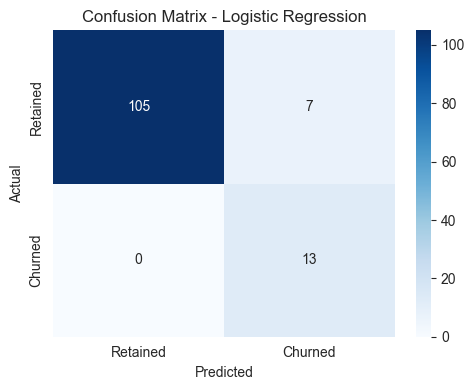

In [33]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

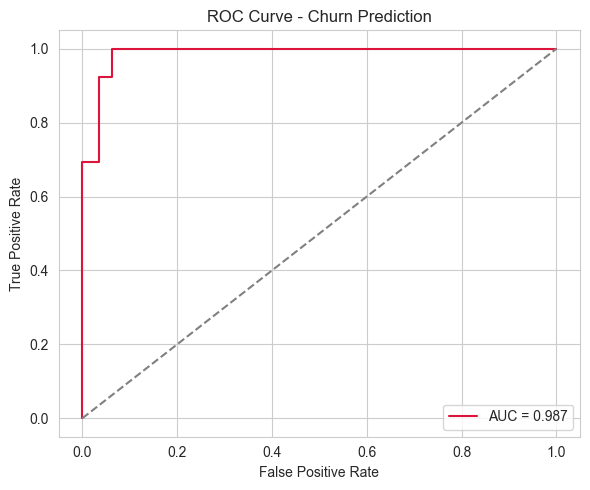

In [34]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}", color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction')
plt.legend()
plt.tight_layout()
folder_name = "graphs_2"
os.makedirs(f"../{folder_name}", exist_ok=True)
plt.savefig(f"../{folder_name}/roc_curve.png", dpi=150)
plt.show()

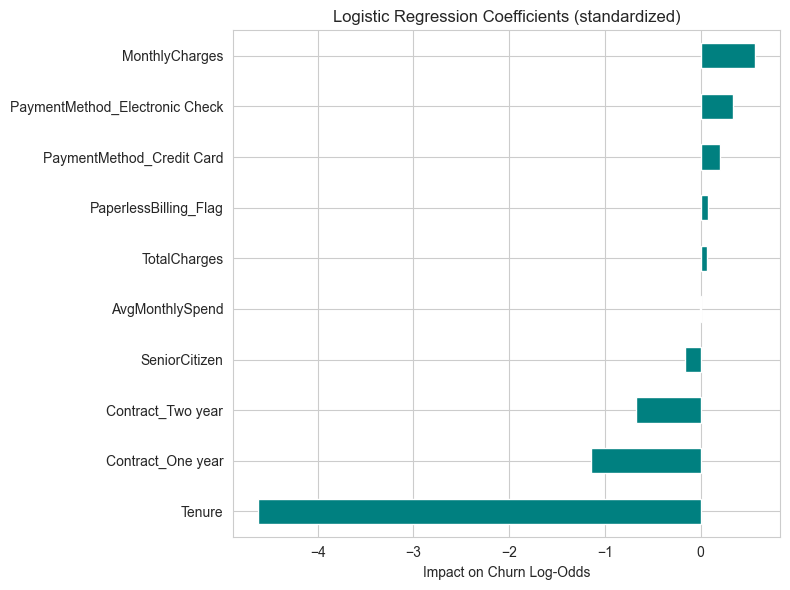

In [35]:
# Feature importance (coefficients)
coef_series = pd.Series(log_model.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
coef_series.plot(kind='barh', color='teal')
plt.title('Logistic Regression Coefficients (standardized)')
plt.xlabel('Impact on Churn Log-Odds')
plt.tight_layout()
os.makedirs(f"../{folder_name}", exist_ok=True)
plt.savefig(f"../{folder_name}/feature_importance_logreg.png", dpi=150)
plt.show()

## 3.3 Cross-check — Random Forest (non-linear model)

In [21]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5,
                                   class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       112
           1       0.86      0.92      0.89        13

    accuracy                           0.98       125
   macro avg       0.92      0.95      0.94       125
weighted avg       0.98      0.98      0.98       125

ROC-AUC: 0.992


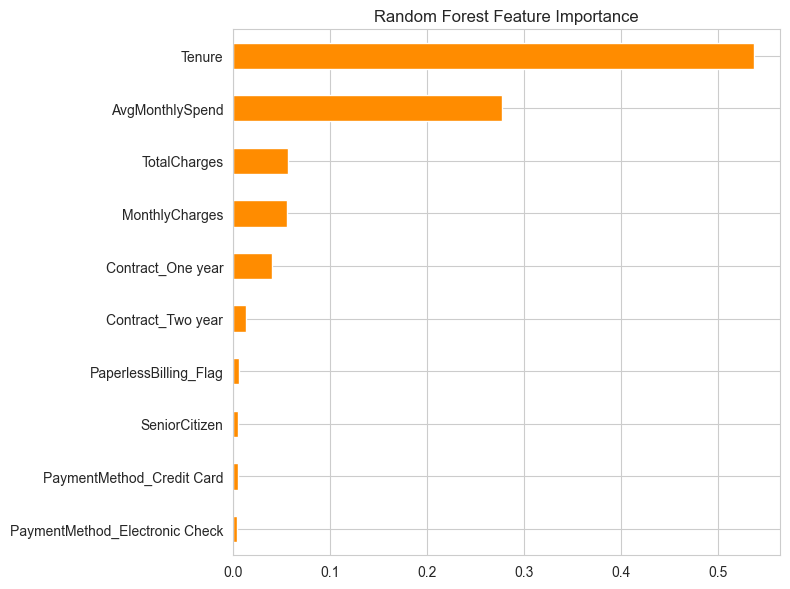

In [36]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
rf_importance.plot(kind='barh', color='darkorange')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
os.makedirs(f"../{folder_name}", exist_ok=True)
plt.savefig(f"../{folder_name}/feature_importance_rf.png", dpi=150)
plt.show()

## 3.4 Validated Findings

- Both models agree: **Contract type, Tenure, and MonthlyCharges** are the top churn predictors.
- Statistical tests confirm these relationships are **not due to chance** (p < 0.05 where noted above).
- Logistic Regression and Random Forest ROC-AUC scores are reported above — model choice can be finalized based on which is higher and more stable.
- These validated drivers feed directly into the recommendations in the executive summary / technical report.
